# 1. Análisis Exploratorio (EDA) e Ingeniería de Características
## 1.1 Carga y Exploración Inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualizaciones
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 8)

# Cargar datos
df = pd.read_csv("../data/ai4i2020.csv")
print(f"Dimensiones: {df.shape}")
print(f"\nPrimeras filas:")
df.head()

Dimensiones: (10000, 14)

Primeras filas:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 1.2 Análisis de Desbalanceo y Distribución de Fallos

Distribución de fallos:
Machine failure    339
TWF                 46
HDF                115
PWF                 95
OSF                 98
RNF                 19
dtype: int64


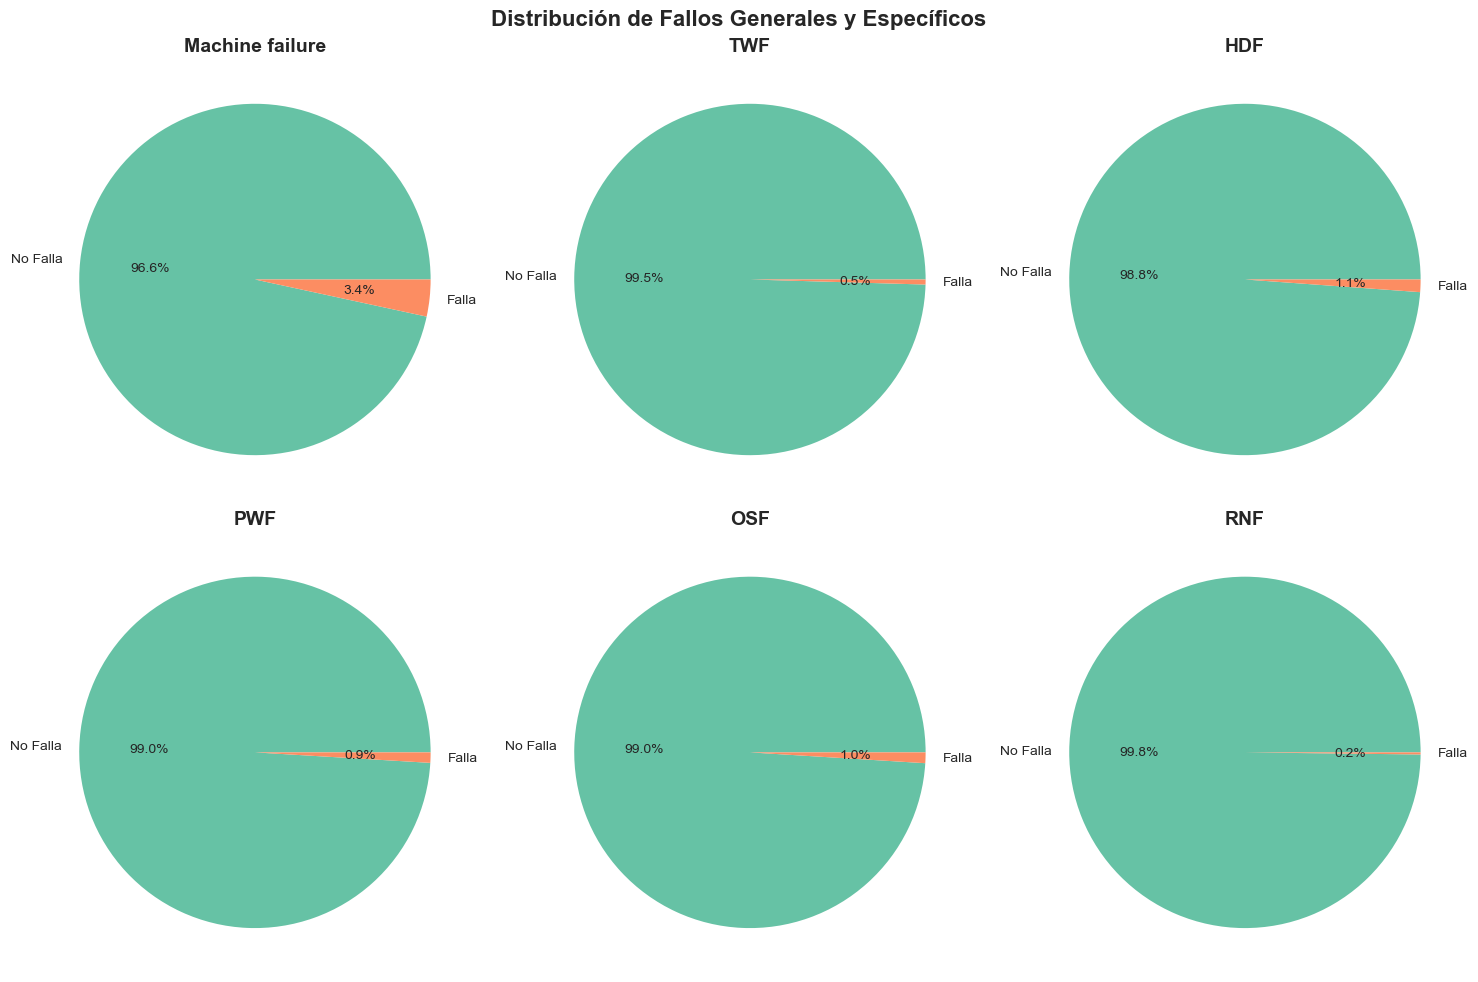

In [2]:
# Análisis de target y modos de fallo
failure_cols = ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

# Estadísticas de fallos
failure_stats = df[failure_cols].sum()
print("Distribución de fallos:")
print(failure_stats)

# Visualización del desbalanceo
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(failure_cols):
    counts = df[col].value_counts()
    axes[i].pie(counts.values, labels=['No Falla', 'Falla'],
                autopct='%1.1f%%')
    axes[i].set_title(f'{col}', fontsize=14, fontweight='bold')

plt.suptitle('Distribución de Fallos Generales y Específicos', fontsize=16,
             fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/failure_distribution.png', dpi=300, 
            bbox_inches='tight')
plt.show()

## 1.3 Ingeniería de Características

In [3]:
# Transformaciones y nuevas características
df_engineered = df.copy()

# Diferencia de temperatura (indicador de estrés térmico)
df_engineered['Temp_Diff'] = df_engineered['Process temperature [K]'] - df_engineered['Air temperature [K]']

# Potencia (Torque x Velocidad angular) - indicador clave para PWF y OSF
# Convertir RPM a rad/s: RPM * (2π/60)
df_engineered['Rotational_speed_rads'] = df_engineered['Rotational speed [rpm]'] * (2 * np.pi / 60)
df_engineered['Power'] = df_engineered['Torque [Nm]'] * df_engineered['Rotational_speed_rads']

# Eficiencia térmica (relación entre calor generado vs. calor disipado)
df_engineered['Thermal_Efficiency'] = (df_engineered['Air temperature [K]'] /
                                       df_engineered['Process temperature [K]']
                                       * 100)

# Interacción: Desgaste x Torque (indicador de sobreesfuerzo acumulado)
df_engineered['Wear_Torque_Interaction'] = (df_engineered['Tool wear [min]']
                                            * df_engineered['Torque [Nm]'])

# Velocidad normalizada por tipo de producto (benchmarking)
type_avg_speed = df_engineered.groupby('Type')['Rotational speed [rpm]'].mean()
df_engineered['Speed_Deviation'] = ((df_engineered['Rotational speed [rpm]']
                                    - df_engineered['Type'].map(type_avg_speed))
                                    / df_engineered['Type'].map(type_avg_speed))

print("Características creadas:")
print(df_engineered[['Temp_Diff', 'Power', 'Thermal_Efficiency', 
                     'Wear_Torque_Interaction', 'Speed_Deviation']].head())

Características creadas:
   Temp_Diff        Power  Thermal_Efficiency  Wear_Torque_Interaction  \
0       10.5  6951.590560           96.597537                      0.0   
1       10.5  6826.722724           96.598639                    138.9   
2       10.4  7749.387543           96.628849                    247.0   
3       10.4  5927.504659           96.629942                    276.5   
4       10.5  5897.816608           96.598639                    360.0   

   Speed_Deviation  
0         0.008716  
1        -0.085399  
2        -0.026937  
3        -0.069160  
4        -0.085399  


## 1.4 Análisis de Correlación y Selección de Features

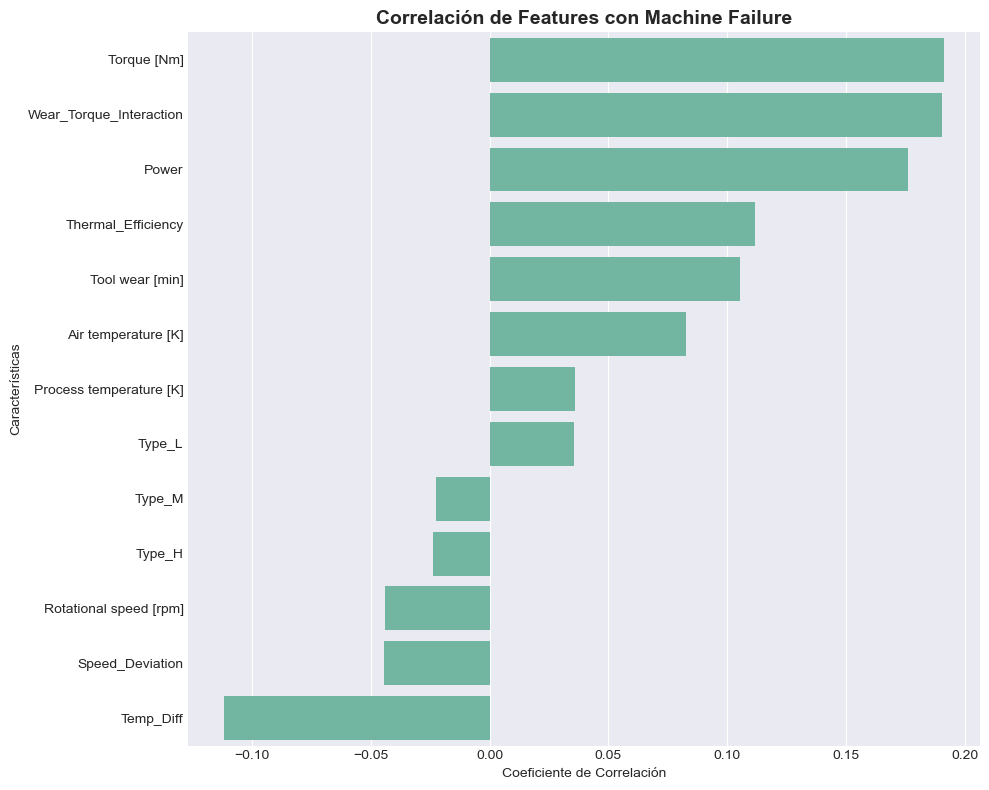

In [4]:
# Seleccionar features para modelado
features = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]',
            'Torque [Nm]', 'Tool wear [min]', 'Temp_Diff', 'Power',
            'Thermal_Efficiency', 'Wear_Torque_Interaction', 'Speed_Deviation']

# Codificar variable categórica 'Type'
df_engineered = pd.get_dummies(df_engineered, columns=['Type'], prefix='Type')
features += ['Type_H', 'Type_L', 'Type_M']

# Matriz de correlación con fallos
correlation_matrix = df_engineered[features + ['Machine failure']].corr()

# Visualizar correlaciones con Machine failure
plt.figure(figsize=(10, 8))
correlation_with_target = correlation_matrix['Machine failure'].sort_values(ascending=False)
sns.barplot(x=correlation_with_target.values[1:], y=correlation_with_target.index[1:])
plt.title('Correlación de Features con Machine Failure', fontsize=14, 
          fontweight='bold')
plt.xlabel('Coeficiente de Correlación')
plt.ylabel('Características')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_with_target.png', dpi=300,
            bbox_inches='tight')
plt.show()

# Guardar dataset procesado
X = df_engineered[features]
y = df_engineered['Machine failure']
y_failure_modes = df_engineered[['TWF', 'HDF', 'PWF', 'OSF', 'RNF']]

# Escalar features numéricas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)

# Guardar datos procesados
X_scaled.to_csv('../data/X_processed.csv', index=False)
y.to_csv('../data/y_target.csv', index=False)
y_failure_modes.to_csv('../data/y_failure_modes.csv', index=False)